# Agilent Technical Interview - Data Science Dataset Work

#### Dataset: 'Data scientist interview dataset_042326_adjusted_r1.xlsx'

##### Prepared By: Kian Ghaffari

### Objectives: 
    1. Perform Data Cleaning on the Dataset
    2. Implement Densification
    3. Identify and Handle Outliers 

### Loading & First Look

In [323]:
# Importing all necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [324]:
# Reading Excel file and converting it into csv file
read_file = pd.read_excel('Data scientist interview dataset_042326_adjusted_r1.xlsx') 

read_file.to_csv('Data scientist interview dataset_042326_adjusted_r1.csv',
                 index = False, header = True) 

df_raw = pd.read_csv("Data scientist interview dataset_042326_adjusted_r1.csv",
                     parse_dates = ['month date']) # converting 'month date' into datetime datatype


In [325]:
# Performing first-look calls as a way of understanding the dataset
print(f"Shape:   {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns") 
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nDtypes:\n{df_raw.dtypes}")             # Checking if month date is datetime
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
print(f"\nTotal Duplicated rows:\n{df_raw.duplicated().sum()}")
df_raw.head()
print(f"\nDescription of raw dataset:\n{df_raw.describe(include = 'all')}")

Shape:   2,898 rows × 10 columns

Columns: ['product_line', 'product_family', 'model_num', 'region', 'plant', 'order_type', 'month date', 'qty_actual', 'average selling price(M)', 'total_est_actual_trade_values(M)']

Dtypes:
product_line                                object
product_family                              object
model_num                                   object
region                                      object
plant                                       object
order_type                                  object
month date                          datetime64[ns]
qty_actual                                   int64
average selling price(M)                   float64
total_est_actual_trade_values(M)           float64
dtype: object

Missing values:
product_line                          0
product_family                        0
model_num                             0
region                                0
plant                                 0
order_type                        

##### General Observations for Data Cleaning
 * Based on column names, it will be necessary to perform standardization
    
 * Examining `plant` column descriptive statistics, 2810 has the highest frequency (will need to confirm it to be string and not integer)
    
 * `month date` column is shown to be datetime and includes observations from 2020-09-01 -> 2026-07-01 
    (No strange dates)
    
 * There are 398 missing values in the `total_est_actual_trade_values(M)` column, will need to fill them with 0 (removing them will be a loss of a good chunk of the data).
    
 * There are 3 duplicated rows found, which will need to be checked.
    
 * Examining the `qty_actual` columns' descriptive statistics, the minimum value is -200 
    (most likely a return or reversal). Any rows with this value will have to be removed as it will distort mean demand and MAPE.
    
 * In the `qty_actual` column, the maximum value is shown to be 150, which could be a sign of outliers.
    
 * `average_selling_price(M)` has a minimum value of 0, which is strange and should be flagged since it is difficult to check whether this is a typo or not

###  Data Cleaning

In [326]:
df = df_raw.copy()

# Standardizing Column names into snakecase to make subsequent code cleaner
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s\(\)]+', '_', regex=True)   # turning spaces and parentheses into _
    .str.replace(r'[^\w]', '_', regex=True)        # turning any remaining specials into _
    .str.replace(r'_+', '_', regex=True)           # collapsing any double __ into _
    .str.strip('_')
)

print(f"Before: {list(df_raw.columns)}")
print(f"\nAfter:  {list(df.columns)}")

Before: ['product_line', 'product_family', 'model_num', 'region', 'plant', 'order_type', 'month date', 'qty_actual', 'average selling price(M)', 'total_est_actual_trade_values(M)']

After:  ['product_line', 'product_family', 'model_num', 'region', 'plant', 'order_type', 'month_date', 'qty_actual', 'average_selling_price_m', 'total_est_actual_trade_values_m']


In [327]:
# Checking the number of integer data types in the coloumn.
n_int_plants = df['plant'].apply(lambda x: isinstance(x, int)).sum() 
df['plant'] = df['plant'].astype(str).str.strip()
print("\n Fixing mixed-type 'plant' column:")
print(f"    {n_int_plants} integer values (e.g. 2810) cast to string '2810'")
print(f"    Unique plants now: {sorted(df['plant'].unique())}")


 Fixing mixed-type 'plant' column:
    0 integer values (e.g. 2810) cast to string '2810'
    Unique plants now: ['2810', 'AY10', 'B410', 'R805', 'R811', 'SG10']


In [328]:
x = ['product_line', 'product_family', 'model_num', 'region', 'plant', 'order_type', 
 'month_date', 'qty_actual', 'average_selling_price_m', 'total_est_actual_trade_values_m']
df[df.duplicated(x, keep = False) == True] # The duplicated rows could be 

df['is_duplicate'] = df.duplicated(keep='first')

n_dupes_flagged = df['is_duplicate'].sum()
print(f"\n Duplicate flagging:")
print(f"    {n_dupes_flagged} duplicate rows flagged with is_duplicate = True")
print(f"    First occurrence kept as canonical record (keep='first')")
print(f"    Rows remain in dataset: {len(df):,}")


 Duplicate flagging:
    3 duplicate rows flagged with is_duplicate = True
    First occurrence kept as canonical record (keep='first')
    Rows remain in dataset: 2,898


In [329]:
neg_rows = df[df['qty_actual'] < 0].copy()
print(f"\n Negative qty_actual:")
print(f" {len(neg_rows)} row(s) found with negative quantity:")
print(neg_rows[['month_date', 'product_family', 'region', 'order_type',
                'qty_actual']])

df = df[df['qty_actual'] >= 0].reset_index(drop = True)
print(f"    Rows after removal: {len(df):,}")


 Negative qty_actual:
 1 row(s) found with negative quantity:
     month_date product_family region    order_type  qty_actual
2879 2025-02-01         eSight    AFO  Trade Orders        -200
    Rows after removal: 2,897


In [330]:
null_by_order_type = df.groupby('order_type').agg(
    null_count=('total_est_actual_trade_values_m', lambda x: x.isnull().sum()))

print(null_by_order_type) # Null values only found in non-trade orders

null_non_trade_types = null_by_order_type[null_by_order_type.index != 0]

mask_non_trade_nan = (
    df['order_type'].isin(null_non_trade_types) &
    df['total_est_actual_trade_values_m'].isna()
)

# Don't want to convert it to the medium since it would fabricate revenue. 
df.loc[mask_non_trade_nan, 'total_est_actual_trade_values_m'] = 0.0 

# Checking for remaining NaN in trade_orders
remaining_nan = df['total_est_actual_trade_values_m'].isna().sum()
if remaining_nan > 0:
    # Impute as qty × asp where possible
    mask_remaining = df['total_est_actual_trade_values_m'].isna()
    df.loc[mask_remaining, 'total_est_actual_trade_values_m'] = (
        df.loc[mask_remaining, 'qty_actual'] * df.loc[mask_remaining, 'average_selling_price_m']
    )
    print(f"\n total_est trade values: {remaining_nan} remaining NaN in "
          f"Trade Orders -> imputed as qty × ASP")
    
    
print(f"\n  Missing total_est_actual_trade_values:")
print(f"    {remaining_nan} NaN values, ALL in non-Trade order types {null_non_trade_types})")
print(f"    Remaining NaN after fill: {df['total_est_actual_trade_values_m'].isna().sum()}")


              null_count
order_type              
Trade Orders           0
ZC1                  308
ZGIO                  42
ZSD1                  35
ZSD2                  13

 total_est trade values: 398 remaining NaN in Trade Orders -> imputed as qty × ASP

  Missing total_est_actual_trade_values:
    398 NaN values, ALL in non-Trade order types               null_count
order_type              
Trade Orders           0
ZC1                  308
ZGIO                  42
ZSD1                  35
ZSD2                  13)
    Remaining NaN after fill: 0


In [331]:
asp_zero = df[df['average_selling_price_m'] == 0]

print(f"\n ASP = 0 rows:")
print(f"    {len(asp_zero)} rows with average selling price = 0")
print(asp_zero[['month_date', 'product_family', 'model_num', 'region',
                'qty_actual', 'average_selling_price_m', 'total_est_actual_trade_values_m']])


df['asp_zero_flag'] = df['average_selling_price_m'] == 0 # Cannot remove 0's but will flag and keep in dataset


 ASP = 0 rows:
    4 rows with average selling price = 0
     month_date    product_family  model_num region  qty_actual  \
2    2025-10-01  Advanteon-CE IVD  2010261CE   APAC           1   
2099 2022-08-01   Quanteon-CE IVD  2010257CE   EMEA           2   
2100 2023-09-01   Quanteon-CE IVD  2010259CE   EMEA           2   
2101 2020-12-01   Quanteon-CE IVD  2010259CE   EMEA           4   

      average_selling_price_m  total_est_actual_trade_values_m  
2                         0.0                              0.0  
2099                      0.0                              0.0  
2100                      0.0                              0.0  
2101                      0.0                              0.0  


In [332]:
# CLEANING SUMMARY
print(f"\n{'─' * 65}")
print("STEP 1 COMPLETE — CLEANING SUMMARY")
print(f"{'─' * 65}")
print(f"  Rows in raw data:         {len(df_raw):,}")
print(f"  Exact duplicates flagged: {n_dupes_flagged}")
print(f"  Negative qty removed:     {len(neg_rows)}")
print(f"  Rows after cleaning:      {len(df):,}")
print(f"  Columns standardized:     {len(df.columns)}")
print(f"  NaN total values filled:  {remaining_nan} (0 for non-Trade orders)")
print(f"  ASP = 0 rows flagged:     {len(asp_zero)}")


─────────────────────────────────────────────────────────────────
STEP 1 COMPLETE — CLEANING SUMMARY
─────────────────────────────────────────────────────────────────
  Rows in raw data:         2,898
  Exact duplicates flagged: 3
  Negative qty removed:     1
  Rows after cleaning:      2,897
  Columns standardized:     12
  NaN total values filled:  398 (0 for non-Trade orders)
  ASP = 0 rows flagged:     4


### Densification

After some research, I've understood densification to be the process of expanding a sparse dataset into a complete, continuous grid by explicitly creating rows for every combination of dimensions across every time period — including periods where no activity occurred.

To keep the number of densified rows to a reasonable amount, I will first aggregate the model-level order data up to the planning grain of **product_family × region × order_type**, since going down to the model_num would be unecessary for planning decisions.

In [333]:
date_spine = pd.date_range(
    start=df['month_date'].min(),
    end=df['month_date'].max(),
    freq='MS'   # Month Start frequency
)
print(f"\nDate spine:")
print(f"    {date_spine[0].date()} → {date_spine[-1].date()}")
print(f"    {len(date_spine)} monthly periods")


Date spine:
    2020-09-01 → 2026-07-01
    71 monthly periods


In [334]:
df_agg = df.groupby(['product_family', 'region', 'order_type'] + ['month_date']).agg(
    qty_actual              = ('qty_actual',  'sum'),
    total_trade_value_m     = ('total_est_actual_trade_values_m', 'sum'),
    avg_selling_price_m     = ('average_selling_price_m',   'mean'),
    n_model_nums            = ('model_num', 'nunique')
).reset_index()

print(f"\n  Aggregated to planning grain:")
print(f"    Dimensions: {['product_family', 'region', 'order_type']}")
print(f"    Rows after aggregation: {len(df_agg):,}")
print(f"    (from {len(df):,} model-level rows)")


  Aggregated to planning grain:
    Dimensions: ['product_family', 'region', 'order_type']
    Rows after aggregation: 1,805
    (from 2,897 model-level rows)


In [335]:
product_families = df_agg['product_family'].unique()
regions       = df_agg['region'].unique()
order_types   = df_agg['order_type'].unique()
 
full_index = pd.MultiIndex.from_product(
    [date_spine, product_families, regions, order_types],
    names=['month_date', 'product_family', 'region', 'order_type']
)
df_template = pd.DataFrame(index=full_index).reset_index()
 
rows_before = len(df_agg)
rows_expected = len(df_template)
 
print(f"\n Full grid construction:")
print(f"    Product families: {len(product_families)}")
print(f"    Regions:          {len(regions)}")
print(f"    Order types:      {len(order_types)}")
print(f"    Months:           {len(date_spine)}")
print(f"    Actual rows:      {rows_before:,}")
print(f"    Full grid rows:   {rows_expected:,}")
print(f"    Rows to be added: {rows_expected - rows_before:,}")  


 Full grid construction:
    Product families: 21
    Regions:          4
    Order types:      5
    Months:           71
    Actual rows:      1,805
    Full grid rows:   29,820
    Rows to be added: 28,015


In [336]:
df_dense = df_template.merge(
    df_agg,
    on=['product_family', 'region', 'order_type'] + ['month_date'],
    # Why LEFT JOIN: started complete grid and attach real data where it exists.
    # Rows that don't match get NaN because these are months where no orders occurred
    how='left'    
)

# Sorting before filling 
df_dense = df_dense.sort_values(
    ['product_family', 'region', 'order_type'] + ['month_date']
).reset_index(drop=True)

# FILL LOGIC:
#   qty_actual = 0        (no orders = zero demand, not unknown)
#   total_trade_value = 0 (no order = no revenue)
#   avg_selling_price = forward-fill within group, then back-fill
#                       (Price doesn't change month to month just
#                       because no orders were placed. The last known
#                       price is the best estimate for a zero-order month.)
#   n_model_nums = 0      (no models ordered)

# Fill demand metrics -> 0
for col in ['qty_actual', 'total_trade_value_m', 'n_model_nums']:
    n_fill = df_dense[col].isna().sum()
    df_dense[col] = df_dense[col].fillna(0)
    print(f"\n    {col}: filled {n_fill:,} new zero-demand months with 0")
 
# Fill price -> forward-fill then back-fill within each planning group
n_asp_nan = df_dense['avg_selling_price_m'].isna().sum()
df_dense['avg_selling_price_m'] = (
    df_dense
    .groupby(['product_family', 'region', 'order_type'])['avg_selling_price_m']
    .transform(lambda x: x.ffill().bfill())
)
remaining = df_dense['avg_selling_price_m'].isna().sum()
print(f"\n    avg_selling_price_m: forward/back-filled {n_asp_nan:,} "
      f"new rows | {remaining} still missing "
      f"(combination never had any orders — expected)")
 
# Flag densified rows so they can be distinguished from real observations
# This helps with future models and dashboards
df_dense['is_densified'] = df_dense['qty_actual'] == 0


    qty_actual: filled 28,015 new zero-demand months with 0

    total_trade_value_m: filled 28,015 new zero-demand months with 0

    n_model_nums: filled 28,015 new zero-demand months with 0

    avg_selling_price_m: forward/back-filled 28,015 new rows | 18744 still missing (combination never had any orders — expected)


In [337]:
coverage = (
    df_dense.groupby(['product_family', 'region', 'order_type'])['month_date']
    .count()
    .reset_index(name='n_months')
)
complete = (coverage['n_months'] == len(date_spine)).sum()
incomplete = (coverage['n_months'] < len(date_spine)).sum()
 
print(f"\n2E. Coverage check:")
print(f"    Fully covered groups (all {len(date_spine)} months): {complete}")
print(f"    Incomplete groups: {incomplete}")
if incomplete > 0:
    print(coverage[coverage['n_months'] < len(date_spine)])
 
print(f"\n{'─' * 65}")
print("STEP 2 COMPLETE — DENSIFICATION SUMMARY")
print(f"{'─' * 65}")
print(f"  Rows before (aggregated): {rows_before:,}")
print(f"  Rows after densification: {len(df_dense):,}")
print(f"  New rows added:           {len(df_dense) - rows_before:,}")
print(f"  Real observations:        {(~df_dense['is_densified']).sum():,}")
print(f"  Densified (zero) rows:    {df_dense['is_densified'].sum():,}")
 
df = df_dense.copy()


2E. Coverage check:
    Fully covered groups (all 71 months): 420
    Incomplete groups: 0

─────────────────────────────────────────────────────────────────
STEP 2 COMPLETE — DENSIFICATION SUMMARY
─────────────────────────────────────────────────────────────────
  Rows before (aggregated): 1,805
  Rows after densification: 29,820
  New rows added:           28,015
  Real observations:        1,805
  Densified (zero) rows:    28,015


### Outlier Handling

After researching different outlier methods, I've realized that using IQR will work better than z-score (which we discussed) since z-score works under the assumption of normality (the data itself is not normal and appears right-skewed)

After identifying outliers, I will cap them instead of removing them since that would create gaps within the time-series. Capping preserves the time period and records that *something* happened that month — just at a bounded level. I also decided on specifically windorization after looking into all possible methods since the only other ones I am familiar with were log transformations (which is best for modeling) and medium imputing (which loses information).

In [338]:
# Only detect outliers on REAL observations — not densified zeros
df_real = df[~df['is_densified']].copy()
df_zero = df[df['is_densified']].copy()

# A densified zero is a structural addition, not a real order.
# Including zeros in IQR computation would pull Q1 to 0 and make the
# lower bound negative, preventing detection of any real anomalies.

print(f"\nOutlier detection applied to real observations only: "
      f"{len(df_real):,} rows")
print(f"Densified zero rows excluded from detection: {len(df_zero):,} rows")


Outlier detection applied to real observations only: 1,805 rows
Densified zero rows excluded from detection: 28,015 rows


In [339]:
def compute_iqr_bounds(series, multiplier=1.5):
    """IQR bounds with lower bound floored at 0 for demand data."""
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = max(Q1 - 1.5 * IQR, 0)
    upper = Q3 + 1.5 * IQR
    return pd.Series({'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                      'lower_bound': lower, 'upper_bound': upper})

bounds = (
    df_real
    .groupby(['product_family', 'region'])['qty_actual']
    .apply(compute_iqr_bounds)
    .unstack()
    .reset_index()
)
 
print(f"\nIQR bounds by product_family × region:")
print(bounds[['product_family', 'region', 'Q1', 'Q3',
              'lower_bound', 'upper_bound']].to_string(index=False))


IQR bounds by product_family × region:
  product_family region   Q1   Q3  lower_bound  upper_bound
Advanteon-CE IVD   APAC 1.00 1.00        1.000        1.000
Advanteon-CE IVD   EMEA 1.00 1.00        1.000        1.000
   Advanteon-IVD   GCFO 1.00 2.00        0.000        3.500
   Advanteon-RUO    AFO 1.00 2.00        0.000        3.500
   Advanteon-RUO   APAC 1.00 1.50        0.250        2.250
   Advanteon-RUO   EMEA 1.00 2.00        0.000        3.500
   Advanteon-RUO   GCFO 2.00 4.00        0.000        7.000
          Cardio    AFO 1.25 1.75        0.500        2.500
          Cardio   EMEA 2.00 2.00        2.000        2.000
          Cardio   GCFO 2.00 2.00        2.000        2.000
       CardioECR    AFO 2.00 2.00        2.000        2.000
       CardioECR   APAC 2.00 2.00        2.000        2.000
       CardioECR   EMEA 2.00 2.00        2.000        2.000
       CardioECR   GCFO 1.00 2.00        0.000        3.500
              DP    AFO 1.00 2.00        0.000        3.500


In [340]:
df_real = df_real.merge(
    bounds[['product_family', 'region', 'lower_bound', 'upper_bound']],
    on=['product_family', 'region'],
    how='left'
)
 
df_real['is_outlier'] = (
    (df_real['qty_actual'] > df_real['upper_bound']) |
    (df_real['qty_actual'] < df_real['lower_bound'])
)
 
n_outliers = df_real['is_outlier'].sum()
print(f"\n Outliers detected: {n_outliers} rows ({n_outliers/len(df_real)*100:.1f}% of real observations)")
 
outlier_detail = (
    df_real[df_real['is_outlier']]
    [['month_date', 'product_family', 'region', 'order_type',
      'qty_actual', 'lower_bound', 'upper_bound']]
    .sort_values('qty_actual', ascending=False)
)
print(f"\nOutlier rows:")
print(outlier_detail.to_string(index=False))


 Outliers detected: 128 rows (7.1% of real observations)

Outlier rows:
month_date product_family region   order_type  qty_actual  lower_bound  upper_bound
2024-10-01  Advanteon-RUO    AFO Trade Orders       150.0        0.000        3.500
2025-05-01   NovoCyte-IVD   GCFO Trade Orders        56.0        0.000       18.000
2021-01-01            S16   GCFO Trade Orders        30.0        0.000        6.000
2020-11-01   NovoCyte-RUO   GCFO Trade Orders        27.0        0.000       13.000
2020-11-01             DP   GCFO Trade Orders        22.0        0.000        3.500
2021-05-01             MP    AFO Trade Orders        18.0        0.000       12.000
2022-09-01  Advanteon-RUO   GCFO Trade Orders        16.0        0.000        7.000
2022-10-01             MP    AFO Trade Orders        16.0        0.000       12.000
2023-01-01             MP    AFO Trade Orders        14.0        0.000       12.000
2022-09-01   NovoCyte-RUO   GCFO Trade Orders        14.0        0.000       13.000
202

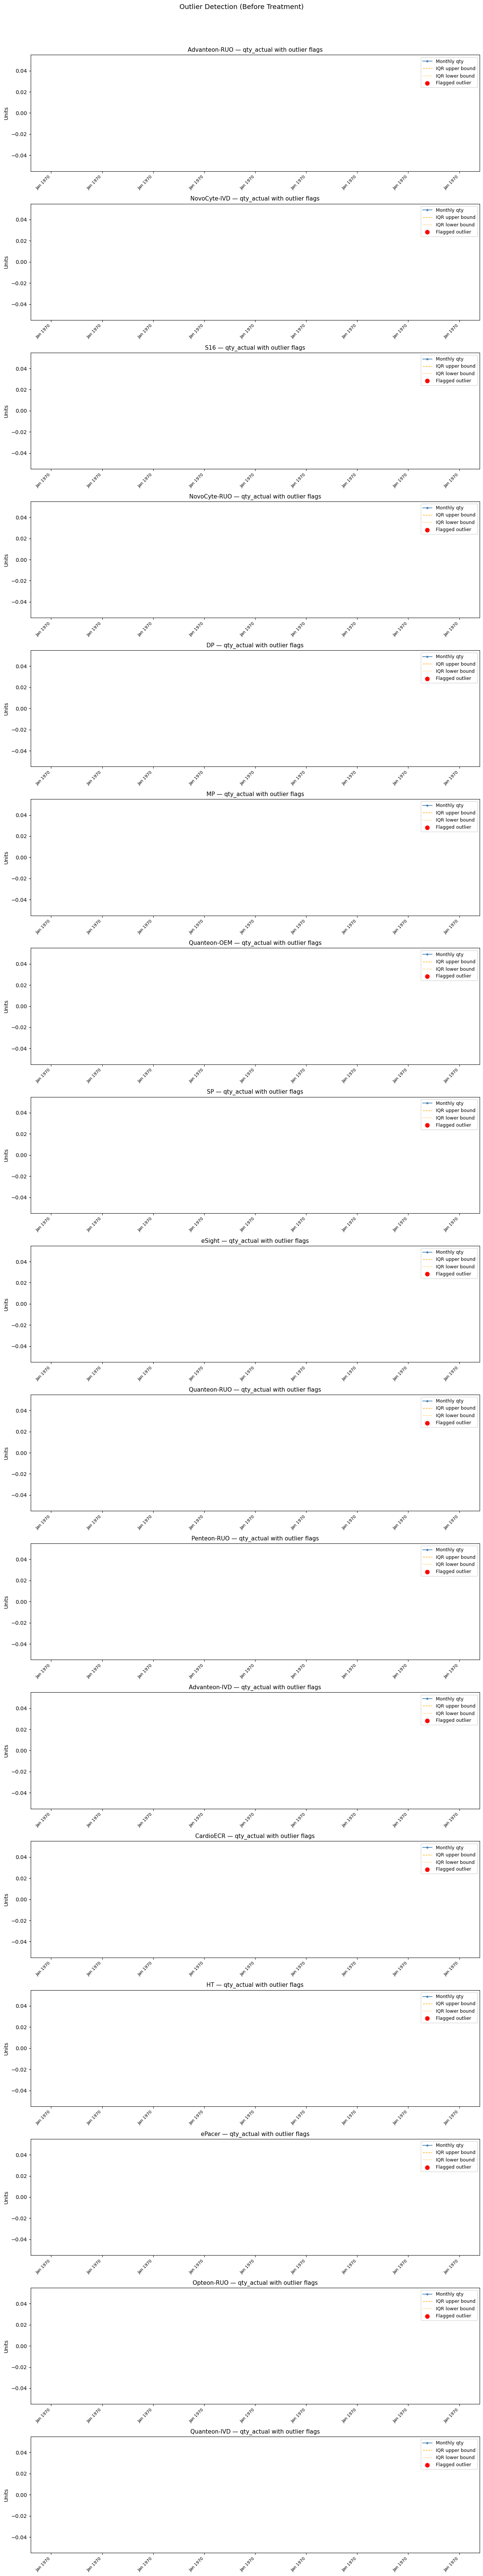

Saved: outliers_before.png


In [342]:
# Visualizing the qty_actual outliers for every product_family
families_with_outliers = outlier_detail['product_family'].unique()
 
fig, axes = plt.subplots(
    len(families_with_outliers), 1,
    figsize=(13, 4 * len(families_with_outliers)),
    sharex=False
)
if len(families_with_outliers) == 1:
    axes = [axes]
 
for ax, fam in zip(axes, families_with_outliers):
    sub = (
        df_real[df_real[['product_family', 'region']] == fam]
        .groupby('month_date')
        .agg(qty=('qty_actual', 'sum'),
             is_outlier=('is_outlier', 'any'),
             upper=('upper_bound', 'mean'),
             lower = ('lower_bound', 'mean'))
        .reset_index()
    )
    ax.plot(sub['month_date'], sub['qty'],
            color='steelblue', linewidth=1.3, marker='o', markersize=3,
            label='Monthly qty')
    ax.plot(sub['month_date'], sub['upper'],
            color='orange', linewidth=1, linestyle='--',
            label='IQR upper bound')
    ax.plot(sub['month_date'], sub['lower'],
        color='orange', linewidth=1, linestyle=':',
        label='IQR lower bound')
    out_pts = sub[sub['is_outlier']]
    ax.scatter(out_pts['month_date'], out_pts['qty'],
               color='red', zorder=5, s=60, label='Flagged outlier') 
    ax.set_title(f'{fam} — qty_actual with outlier flags', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylabel('Units')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
 
plt.suptitle('Outlier Detection (Before Treatment)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outliers_before.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outliers_before.png")

In [319]:
# Preserve original values for audit
df_real['qty_actual_raw'] = df_real['qty_actual'].copy()
 
# Cap
df_real['qty_actual'] = df_real['qty_actual'].clip(
    lower=df_real['lower_bound'],
    upper=df_real['upper_bound']
)
 
n_capped = (df_real['qty_actual_raw'] != df_real['qty_actual']).sum()
print(f"\n Winsorization applied:")
print(f"    {n_capped} values capped at their group upper bound")
 
capped_detail = df_real[df_real['qty_actual_raw'] != df_real['qty_actual']][[
    'month_date', 'product_family', 'region', 'order_type',
    'qty_actual_raw', 'qty_actual', 'upper_bound', 'lower_bound'
]].rename(columns={
    'qty_actual_raw': 'original_qty',
    'qty_actual': 'capped_qty'
})
print(capped_detail.to_string(index=False))

# Recalculate total trade value for capped rows to remain consistent (new qty * original asp)
mask_capped = df_real['qty_actual_raw'] != df_real['qty_actual']
df_real.loc[mask_capped, 'total_trade_value_m'] = (
    df_real.loc[mask_capped, 'qty_actual']
    * df_real.loc[mask_capped, 'avg_selling_price_m']
)
print(f"Total trade value recalculated for {mask_capped.sum()} capped rows")


 Winsorization applied:
    128 values capped at their group upper bound
month_date product_family region   order_type  original_qty  capped_qty  upper_bound  lower_bound
2022-11-01  Advanteon-IVD   GCFO Trade Orders           5.0       3.500        3.500        0.000
2023-02-01  Advanteon-IVD   GCFO Trade Orders           4.0       3.500        3.500        0.000
2024-11-01  Advanteon-IVD   GCFO Trade Orders           6.0       3.500        3.500        0.000
2023-08-01  Advanteon-RUO    AFO Trade Orders           4.0       3.500        3.500        0.000
2024-02-01  Advanteon-RUO    AFO Trade Orders           4.0       3.500        3.500        0.000
2024-09-01  Advanteon-RUO    AFO Trade Orders           5.0       3.500        3.500        0.000
2024-10-01  Advanteon-RUO    AFO Trade Orders         150.0       3.500        3.500        0.000
2021-09-01  Advanteon-RUO   APAC Trade Orders           3.0       2.250        2.250        0.250
2023-01-01  Advanteon-RUO   APAC Trade Order

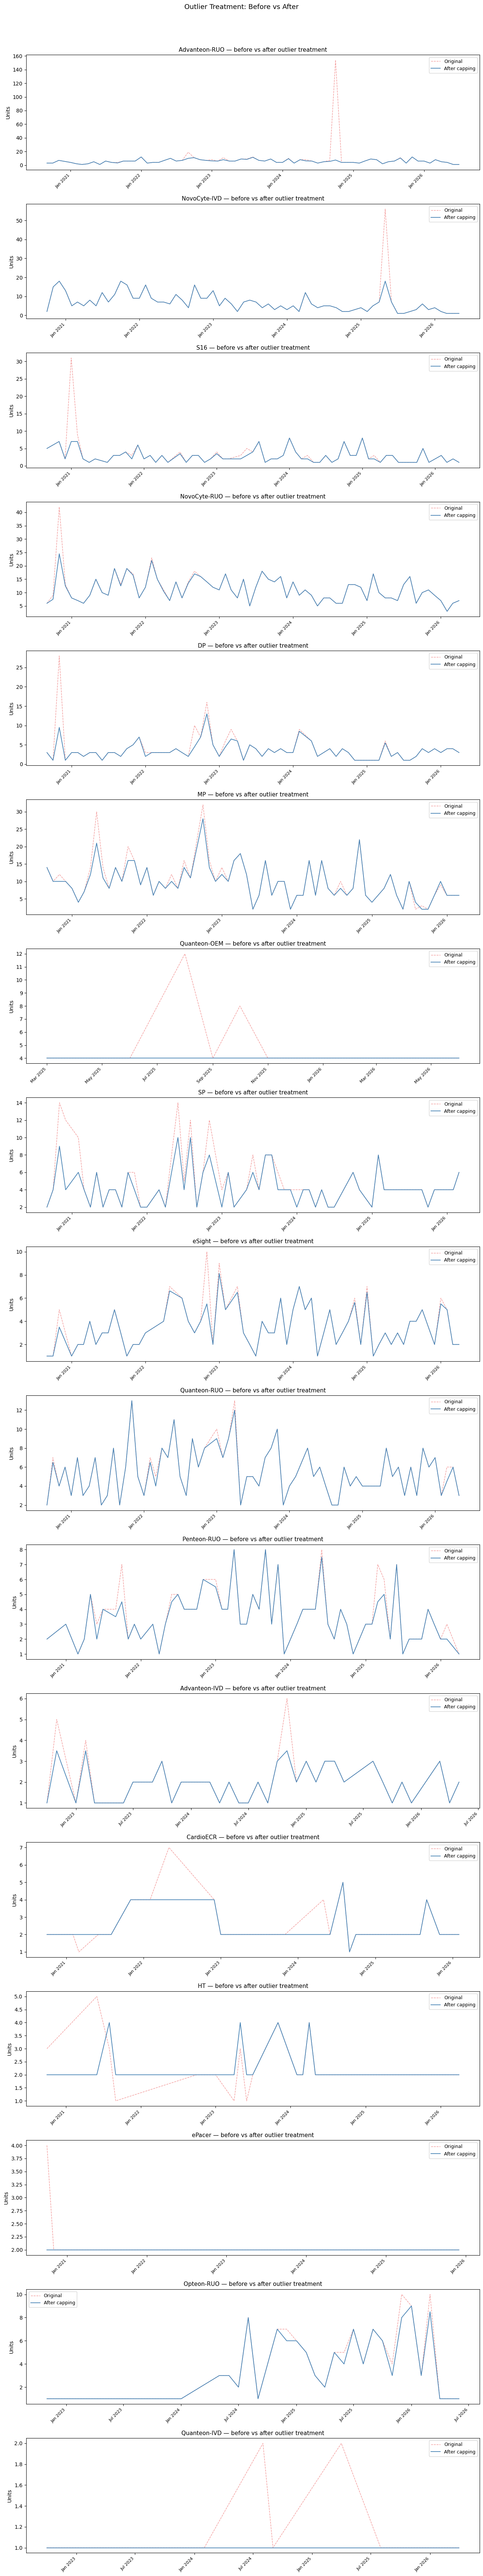

    Saved: outliers_after.png


In [320]:
# Visualizing qty_actual after capping and comparing it to before
fig, axes = plt.subplots(
    len(families_with_outliers), 1,
    figsize=(13, 4 * len(families_with_outliers)),
    sharex=False
)
if len(families_with_outliers) == 1:
    axes = [axes]
 
for ax, fam in zip(axes, families_with_outliers):
    sub = (
        df_real[df_real['product_family'] == fam]
        .groupby('month_date')
        .agg(
            qty_raw   = ('qty_actual_raw', 'sum'),
            qty_clean = ('qty_actual', 'sum')
        )
        .reset_index()
    )
    ax.plot(sub['month_date'], sub['qty_raw'],
            color='lightcoral', linewidth=1, linestyle='--',
            alpha=0.8, label='Original')
    ax.plot(sub['month_date'], sub['qty_clean'],
            color='steelblue', linewidth=1.3, label='After capping')
    ax.set_title(f'{fam} — before vs after outlier treatment', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylabel('Units')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
 
plt.suptitle('Outlier Treatment: Before vs After',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outliers_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("    Saved: outliers_after.png")

In [321]:
# Adding qty_actual_raw column to densified rows (it equals 0 for all of them)
df_zero['qty_actual_raw'] = 0.0
df_zero['lower_bound'] = np.nan
df_zero['upper_bound'] = np.nan
df_zero['is_outlier'] = False
 
# Drop helper bound columns from real data before concat
df_real_clean = df_real.drop(columns=['lower_bound', 'upper_bound'])
 
df_final = pd.concat([df_real_clean, df_zero], ignore_index=True)
df_final = df_final.sort_values(['product_family', 'region', 'order_type'] + 
                                ['month_date']).reset_index(drop=True)
 
print(f"\n Recombined dataset: {len(df_final):,} rows")
 
# Impact summary
print(f"\nStatistical impact of outlier treatment on qty_actual:")
comparison = pd.DataFrame({
    'Before capping': df_real['qty_actual_raw'].describe(),
    'After capping':  df_real['qty_actual'].describe()
}).round(3)
print(comparison)


 Recombined dataset: 29,820 rows

Statistical impact of outlier treatment on qty_actual:
       Before capping  After capping
count        1805.000       1805.000
mean            2.512          2.279
std             4.381          2.041
min             1.000          1.000
25%             1.000          1.000
50%             2.000          2.000
75%             3.000          2.000
max           150.000         18.000


In [322]:
# Dropping columns used internally that shouldn't go in the final deliverable
internal_cols = ['asp_zero_flag', 'is_outlier', 'lower_bound','upper_bound']
df_output = df_final.drop(
    columns=[c for c in internal_cols if c in df_final.columns]
)
 
print("\n" + "=" * 65)
print("PIPELINE COMPLETE — FINAL DATASET")
print("=" * 65)
print(f"\nShape:   {df_output.shape[0]:,} rows × {df_output.shape[1]} columns")
print(f"Columns: {list(df_output.columns)}")
print(f"\nDate range: {df_output['month_date'].min().date()} -> "
      f"{df_output['month_date'].max().date()}")
print(f"\nDescriptive statistics:\n{df_output.describe().round(4)}")

df_output.to_excel('agilent_demand_clean_final.xlsx', index=False)


PIPELINE COMPLETE — FINAL DATASET

Shape:   29,820 rows × 10 columns
Columns: ['month_date', 'product_family', 'region', 'order_type', 'qty_actual', 'total_trade_value_m', 'avg_selling_price_m', 'n_model_nums', 'is_densified', 'qty_actual_raw']

Date range: 2020-09-01 -> 2026-07-01

Descriptive statistics:
                          month_date  qty_actual  total_trade_value_m  \
count                          29820  29820.0000           29820.0000   
mean   2023-08-01 12:50:42.253520896      0.1380               0.0110   
min              2020-09-01 00:00:00      0.0000               0.0000   
25%              2022-02-01 00:00:00      0.0000               0.0000   
50%              2023-08-01 00:00:00      0.0000               0.0000   
75%              2025-02-01 00:00:00      0.0000               0.0000   
max              2026-07-01 00:00:00     18.0000               0.9657   
std                              NaN      0.7399               0.0573   

       avg_selling_price_m  n_mod